<a href="https://colab.research.google.com/github/nicholas-schwier-class/Computational-Probability-and-Stats-2026/blob/main/Ch4_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Uniform Distribution Example

Suppose a bus arrives randomly and uniformly between
7:00 AM and 7:20 AM.

That means:

Every minute between 0 and 20 minutes after 7:00 AM is equally likely.

This follows a Uniform(0, 20) distribution (measured in minutes).

Mean arrival time = 10 minutes after 7:00 AM (7:10 AM)

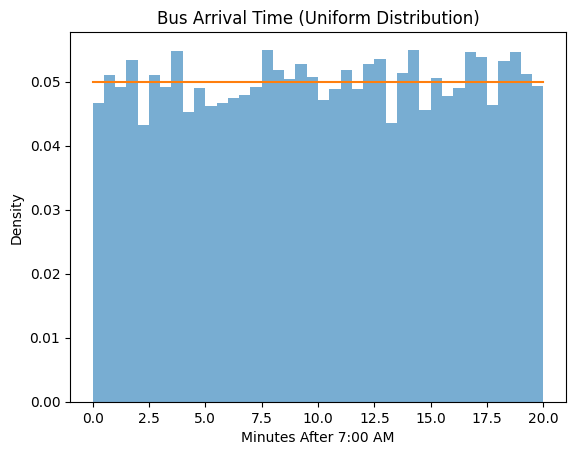

Expected Arrival Time: 10.0 minutes after 7:00 AM
Probability bus arrives before 7:05 AM: 0.25
Probability bus arrives between 7:05 and 7:15 AM: 0.5
Sample Mean: 10.089355068448238


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

# -----------------------------
# Real-life scenario
# -----------------------------
# Bus arrives between 7:00 and 7:20 AM
a = 0     # minutes after 7:00 AM
b = 20    # 20 minutes after 7:00 AM

# -----------------------------
# Simulate 10,000 days of arrivals
# -----------------------------
arrival_times = np.random.uniform(a, b, 10000)

# -----------------------------
# Probability calculations
# -----------------------------
# Probability bus arrives before 7:05 AM
prob_before_5 = uniform.cdf(5, loc=a, scale=b-a)

# Probability bus arrives between 7:05 and 7:15 AM
prob_5_to_15 = uniform.cdf(15, loc=a, scale=b-a) - uniform.cdf(5, loc=a, scale=b-a)

# -----------------------------
# Plot histogram and PDF
# -----------------------------
x = np.linspace(a, b, 500)
pdf = uniform.pdf(x, loc=a, scale=b-a)

plt.hist(arrival_times, bins=40, density=True, alpha=0.6)
plt.plot(x, pdf)

plt.title("Bus Arrival Time (Uniform Distribution)")
plt.xlabel("Minutes After 7:00 AM")
plt.ylabel("Density")
plt.show()

# -----------------------------
# Output results
# -----------------------------
print("Expected Arrival Time:", (a + b) / 2, "minutes after 7:00 AM")
print("Probability bus arrives before 7:05 AM:", prob_before_5)
print("Probability bus arrives between 7:05 and 7:15 AM:", prob_5_to_15)
print("Sample Mean:", np.mean(arrival_times))

2. Exponential Distribution Example

Suppose a coffee shop observes that, on average,
3 customers arrive per minute.

When events happen:

Randomly

Independently

At a constant average rate

The waiting time between arrivals follows an Exponential distribution.

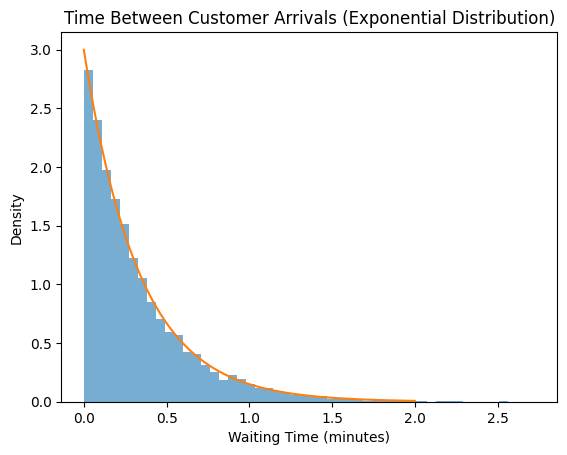

Average waiting time (theoretical): 0.3333333333333333 minutes
Sample mean waiting time: 0.3258329848967449
Probability next customer arrives within 30 seconds: 0.7768698398515702


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

# -----------------------------
# Real-world parameter
# -----------------------------
lambda_rate = 3  # customers per minute
scale = 1 / lambda_rate  # scipy uses scale = 1/lambda

# -----------------------------
# Simulate real arrival data
# -----------------------------
np.random.seed(42)
waiting_times = np.random.exponential(scale, 10000)

# -----------------------------
# Theoretical PDF
# -----------------------------
x = np.linspace(0, 2, 500)
pdf = expon.pdf(x, scale=scale)

# -----------------------------
# Plot
# -----------------------------
plt.hist(waiting_times, bins=50, density=True, alpha=0.6)
plt.plot(x, pdf)

plt.title("Time Between Customer Arrivals (Exponential Distribution)")
plt.xlabel("Waiting Time (minutes)")
plt.ylabel("Density")
plt.show()

# -----------------------------
# Probability Example
# -----------------------------
# Probability next customer arrives within 30 seconds (0.5 minutes)
prob_less_than_30_sec = expon.cdf(0.5, scale=scale)

print("Average waiting time (theoretical):", scale, "minutes")
print("Sample mean waiting time:", np.mean(waiting_times))
print("Probability next customer arrives within 30 seconds:", prob_less_than_30_sec)

Example: Gamma Distribution in Python

The Gamma distribution is commonly used to model:

Waiting time until the k-th event

*   Service times
*   Rainfall amounts

It has two parameters:

shape (k) – number of events

scale (θ) – average time between events

Mean =
𝑘
𝜃


Variance =
𝑘
𝜃
2


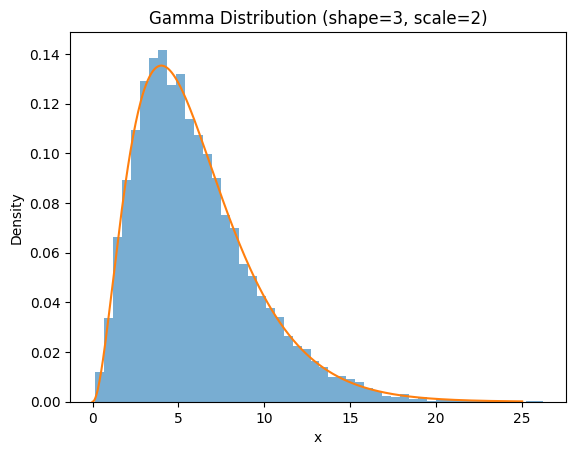

Theoretical Mean: 6
Theoretical Variance: 12
Sample Mean: 5.9683802327611835
Sample Variance: 11.737521789492474


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

# -----------------------------
# Parameters
# -----------------------------
shape = 3        # k (shape parameter)
scale = 2        # theta (scale parameter)

# -----------------------------
# Generate random data
# -----------------------------
data = gamma.rvs(a=shape, scale=scale, size=10000)

# -----------------------------
# Create x values for PDF
# -----------------------------
x = np.linspace(0, 25, 500)
pdf = gamma.pdf(x, a=shape, scale=scale)

# -----------------------------
# Plot Histogram and PDF
# -----------------------------
plt.hist(data, bins=50, density=True, alpha=0.6)
plt.plot(x, pdf)

plt.title("Gamma Distribution (shape=3, scale=2)")
plt.xlabel("x")
plt.ylabel("Density")
plt.show()

# -----------------------------
# Print theoretical values
# -----------------------------
mean = shape * scale
variance = shape * scale**2

print("Theoretical Mean:", mean)
print("Theoretical Variance:", variance)
print("Sample Mean:", np.mean(data))
print("Sample Variance:", np.var(data))

3. Normal Distribution Example
Heights of adult males in many populations are approximately normally distributed.

We’ll use a commonly cited real-world summary:

Mean height ≈ 175 cm

Standard deviation ≈ 7 cm

We will:

Simulate a realistic dataset of heights

Plot the data

Overlay the theoretical Normal curve

Compute real probabilities

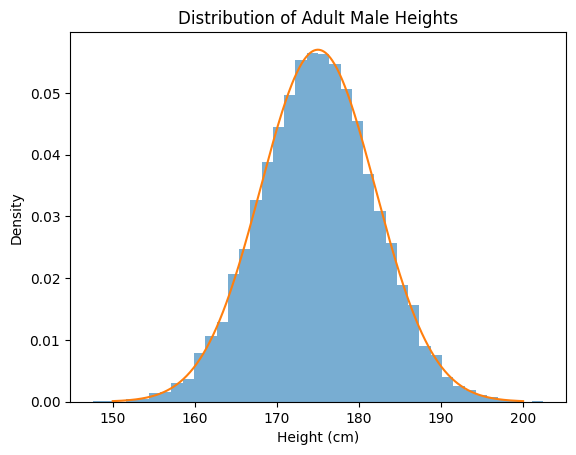

Sample Mean: 174.985048116421
Sample Standard Deviation: 7.023885442909912
Probability taller than 185 cm: 0.07656372550983481
Probability between 170 and 180 cm: 0.5249494759460469


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# -----------------------------
# Real-world parameters
# -----------------------------
mean_height = 175   # cm
std_height = 7      # cm

# -----------------------------
# Simulate real-world data
# -----------------------------
np.random.seed(42)
heights = np.random.normal(mean_height, std_height, 10000)

# -----------------------------
# Create theoretical PDF
# -----------------------------
x = np.linspace(150, 200, 500)
pdf = norm.pdf(x, mean_height, std_height)

# -----------------------------
# Plot histogram and PDF
# -----------------------------
plt.hist(heights, bins=40, density=True, alpha=0.6)
plt.plot(x, pdf)

plt.title("Distribution of Adult Male Heights")
plt.xlabel("Height (cm)")
plt.ylabel("Density")
plt.show()

# -----------------------------
# Probability calculations
# -----------------------------
# Probability someone is taller than 185 cm
prob_tall = 1 - norm.cdf(185, mean_height, std_height)

# Probability someone is between 170 and 180 cm
prob_middle = norm.cdf(180, mean_height, std_height) - norm.cdf(170, mean_height, std_height)

print("Sample Mean:", np.mean(heights))
print("Sample Standard Deviation:", np.std(heights))
print("Probability taller than 185 cm:", prob_tall)
print("Probability between 170 and 180 cm:", prob_middle)

Suppose we collect exam scores from 100 students and want to check if the distribution is approximately normal.

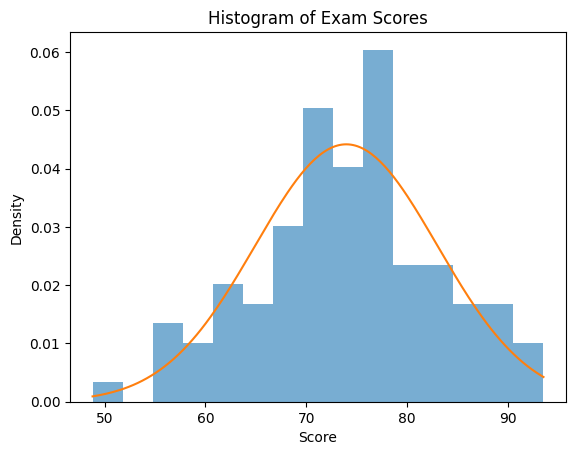

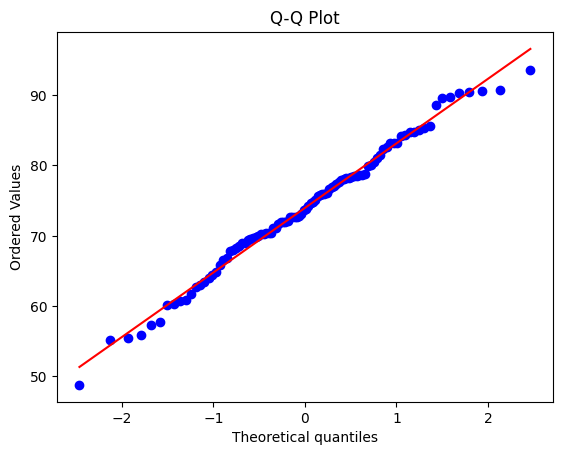

Shapiro-Wilk Test Statistic: 0.9898833815158516
p-value: 0.6551676754214818
Data looks approximately normal (fail to reject H0).
Skewness: -0.17526772024433837
Kurtosis: -0.15540470774207993


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# -----------------------------
# Generate example data
# (Normally distributed scores)
# -----------------------------
np.random.seed(42)
scores = np.random.normal(loc=75, scale=10, size=100)

# -----------------------------
# 1. Histogram
# -----------------------------
plt.hist(scores, bins=15, density=True, alpha=0.6)

x = np.linspace(min(scores), max(scores), 200)
plt.plot(x, stats.norm.pdf(x, np.mean(scores), np.std(scores)))

plt.title("Histogram of Exam Scores")
plt.xlabel("Score")
plt.ylabel("Density")
plt.show()

# -----------------------------
# 2. Q-Q Plot
# -----------------------------
stats.probplot(scores, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

# -----------------------------
# 3. Shapiro-Wilk Test
# -----------------------------
stat, p_value = stats.shapiro(scores)

print("Shapiro-Wilk Test Statistic:", stat)
print("p-value:", p_value)

if p_value > 0.05:
    print("Data looks approximately normal (fail to reject H0).")
else:
    print("Data is NOT normal (reject H0).")

# -----------------------------
# 4. Skewness and Kurtosis
# -----------------------------
print("Skewness:", stats.skew(scores))
print("Kurtosis:", stats.kurtosis(scores))

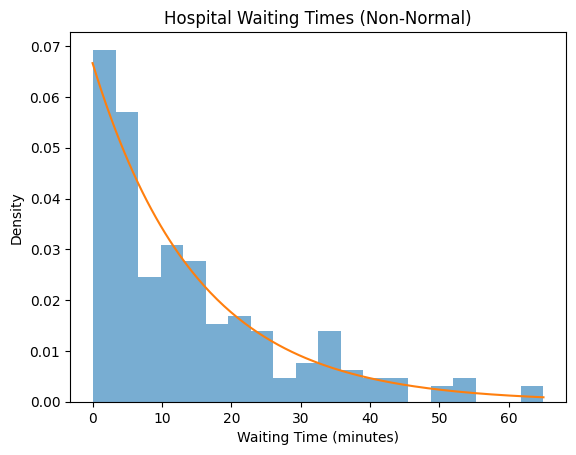

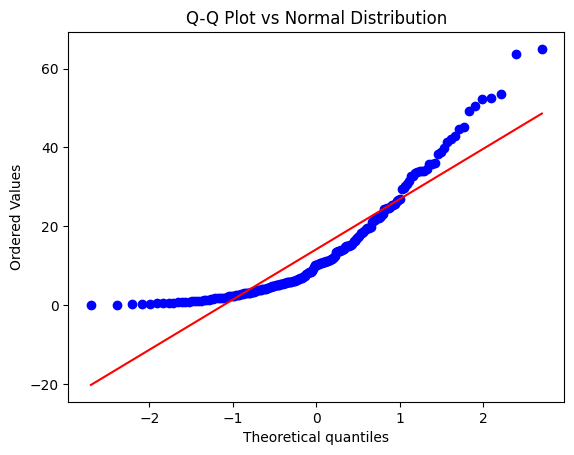

Shapiro-Wilk p-value: 5.532478172231605e-13
Data is NOT normal.
Skewness: 1.3663300866716612


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# -----------------------------
# Simulate real-world waiting times
# -----------------------------
np.random.seed(42)
waiting_times = np.random.exponential(scale=15, size=200)
# scale = 15 minutes average waiting time

# -----------------------------
# Histogram
# -----------------------------
plt.hist(waiting_times, bins=20, density=True, alpha=0.6)

x = np.linspace(0, max(waiting_times), 200)
plt.plot(x, stats.expon.pdf(x, scale=15))

plt.title("Hospital Waiting Times (Non-Normal)")
plt.xlabel("Waiting Time (minutes)")
plt.ylabel("Density")
plt.show()

# -----------------------------
# Q-Q Plot against Normal
# -----------------------------
stats.probplot(waiting_times, dist="norm", plot=plt)
plt.title("Q-Q Plot vs Normal Distribution")
plt.show()

# -----------------------------
# Shapiro-Wilk Test
# -----------------------------
stat, p_value = stats.shapiro(waiting_times)

print("Shapiro-Wilk p-value:", p_value)

if p_value > 0.05:
    print("Data looks approximately normal.")
else:
    print("Data is NOT normal.")

# -----------------------------
# Skewness
# -----------------------------
print("Skewness:", stats.skew(waiting_times))